# Relatório Técnico — Tech Challenge Fase 4

**Tema:** Monitoramento multimodal de pacientes em reabilitação/UTI com detecção de anomalias em tempo real

**Curso:** Pós FIAP — 8IADT · Fase 4  
**Projeto:** TechChallenge Multimodais  
**Stack:** local e gratuita (MediaPipe, YOLOv8, Whisper, PyOD, Ollama + LoRA médico)

> **Aviso educacional:** este sistema e o modelo LLM médico associado são **educacionais**.  
> Não substituem avaliação, diagnóstico ou tratamento por profissional de saúde.

## 1. Problema e objetivo

Com a IA já integrada a processos médicos (exames, documentos e apoio à decisão), o hospital deseja **monitorar continuamente** os pacientes por meio de dados multimodais — **vídeo, áudio e sinais vitais/texto clínico** — para identificar sinais precoces de risco.

Neste trabalho, o fio condutor é um **paciente fictício** em reabilitação / UTI simulada. Isso encaixa os três blocos do enunciado:

| Modalidade | Cenário | O que detectamos |
|---|---|---|
| **Vídeo** | Sessões de fisioterapia | Padrões de movimento / postura anômalos |
| **Áudio** | Consultas / check-ins de voz | Fadiga, disartria, termos críticos |
| **Anomalias** | Sinais vitais + prescrição | Desvios em HR/SpO₂/PA e evolução inesperada do tratamento |

### Objetivos

1. Analisar e **fundir** diferentes tipos de dados médicos (vídeo, áudio, séries temporais e texto de prescrição).
2. Aplicar **detecção de anomalias** (incluindo simulação de tempo quase real por janelas).
3. Gerar **alertas e resumos clínicos** para a equipe médica via motor de LLM local.
4. Documentar a solução completa (código, relatório e demo em vídeo).

## 2. Arquitetura multimodal

Cada modalidade tem processamento especializado; os scores convergem na fusão e o motor de alertas (LLM) produz o resumo para a equipe.

```text
┌─────────────────┐   ┌─────────────────┐   ┌─────────────────┐
│ Vídeo           │   │ Áudio           │   │ Sinais vitais   │
│ (fisioterapia)  │   │ (consulta)      │   │ HR / SpO₂ / PA  │
└────────┬────────┘   └────────┬────────┘   └────────┬────────┘
         │                     │                     │
         ▼                     ▼                     ▼
┌─────────────────┐   ┌─────────────────┐   ┌─────────────────┐
│ Análise postural│   │ Transcrição NLP │   │ Anomalias       │
│ MediaPipe+YOLOv8│   │ Whisper+Transform│  │ IsolationForest │
└────────┬────────┘   └────────┬────────┘   └────────┬────────┘
         │                     │                     │
         └──────────┬──────────┴──────────┬──────────┘
                    ▼                     ▼
           ┌────────────────┐    ┌────────────────┐
           │ Fusão multimodal│───▶│ Motor de alertas│
           │ (3 scores)      │    │ LLM local      │
           └────────────────┘    └────────┬───────┘
                                          ▼
                                 ┌────────────────┐
                                 │ Equipe médica  │
                                 └────────────────┘
```

### Mapeamento no repositório

| Etapa | Pacote |
|---|---|
| Pose / anomalia motora | `src/video/` (`pose_estimation.py`, `anomaly_report.py`) |
| Transcrição / fala | `src/audio/` (`transcription.py`, `speech_analysis.py`) |
| Vitais / prescrição | `src/vitals/` (`anomaly_detection.py`, `prescription_check.py`) |
| Fusão de risco | `src/fusion/risk_fusion.py` |
| Relatório LLM | `src/llm/ollama_report.py` |
| Notificações | `src/alerts/notifier.py` |
| Modelos locais | `.env` → `LOCAL_LLAMA_MODEL_PATH`, `MEDICAL_ADAPTER_PATH` |

## 3. Requisitos do enunciado × solução adotada

O PDF da Fase 4 cita **Azure Cognitive Services**. Optamos por **stack gratuita local**, com equivalência funcional documentada abaixo (aceitável academicamente desde que justificado).

| Requisito (PDF) | Solução local | Status |
|---|---|---|
| Análise de vídeo (fisio/cirurgia) | MediaPipe Pose + assimetria L/R | Executado (`src/video`) |
| OpenPose / postura | **MediaPipe Pose** (alternativa ao OpenPose) | Executado (assimetria) |
| YOLOv8 (objetos / áreas) | Ultralytics YOLOv8 | Planejado |
| Relatório de desvios no procedimento | `anomaly_report.py` (heurística) | Executado (MVP) |
| Áudio de consultas | Whisper (STT) | Planejado (`src/audio`) |
| Azure Speech to Text | **Whisper** | Equivalente local |
| Azure Text Analytics (termos/sentimento) | **Transformers** + regras de termos críticos | Equivalente local |
| Fadiga / disartria | Features UCI Parkinson (`parkinsons_analysis.py`) | Executado (tabular) |
| Anomalias em vitais | Isolation Forest (sklearn) | Executado (v1 sintético) |
| Evolução de prescrições | `prescription_check.py` (texto/regras) | Planejado |
| Alertas à equipe | Fusão + Ollama + `notifier.py` | Planejado |
| Serviços em nuvem Azure | Stack local + Ollama; LoRA médico no HF | Substituído / justificado |

### Tabela de equivalência Azure → local

| Azure (enunciado) | Equivalente gratuito |
|---|---|
| Speech to Text | OpenAI Whisper |
| Text Analytics | Hugging Face Transformers + léxico clínico |
| Cognitive / resumo | Ollama (`llama3.2`) + adapter LoRA médico |
| Pipeline gerenciado | Scripts Python + notebooks neste repositório |

## 4. Datasets e justificativa acadêmica

### Estratégia do MVP

Para validar o pipeline com rapidez e facilitar o relatório técnico, o MVP usa **dados controlados**:

| Modalidade | MVP (agora) | Próximo passo (público) |
|---|---|---|
| Vitais | **MIT-BIH Arrhythmia + NSRDB** (treino) + high-risk fragments (extra) | MIMIC Waveform / vitais sintéticos auxiliares |
| Áudio | **UCI Parkinson** (features em `data/raw/parkinsons/`) | Coswara / Saarbrücken / Whisper em WAV |
| Vídeo | Clipe próprio em `data/raw/videos/` + assimetria MediaPipe | UCF101 / NTU RGB+D; YOLOv8 opcional |

### Por que isso é aceitável

- Datasets clínicos públicos de **fisioterapia completa** são raros.
- Séries sintéticas com anomalias **conhecidas** permitem medir se o detector acerta (ground truth controlado).
- Vídeo próprio / ação humana genérica adaptada é prática comum em trabalhos acadêmicos — desde que as **limitações** estejam explícitas no relatório.

### Fontes sugeridas pelo enunciado / literatura

- PhysioNet: https://physionet.org/
- AudioSet (auxiliar): https://research.google.com/audioset/
- Adapter médico: https://huggingface.co/StefanieFranco/llama3-medical-fine-tuning

Dados brutos → `data/raw/` · processados → `data/processed/`.


### 4.1 Fontes PhysioNet de ECG (vitais)

Para o bloco de **sinais vitais / anomalias**, usamos três bases PhysioNet sob `data/raw/vitals/`:

| Pasta | Dataset | Papel |
|---|---|---|
| `mitdb/` | [MIT-BIH Arrhythmia](https://physionet.org/content/mitdb/1.0.0/) | Treino (normal + arritmia anotada) |
| `nsrdb/` | [MIT-BIH Normal Sinus Rhythm](https://physionet.org/content/nsrdb/1.0.0/) | Treino (baseline de ritmo normal) |
| `ecg-fragment-high-risk/` | [ECG Fragment High-Risk](https://physionet.org/content/ecg-fragment-high-risk-label/1.0.0/) | Experimento extra de **sensibilidade** a eventos críticos |

**União de treino:** apenas `mitdb` + `nsrdb` → `data/processed/vitals/arrhythmia_train.parquet`.  
O dataset de fragmentos de alto risco **não** entra nessa união (fica reservado para teste de sensibilidade).


### 4.2 Importação via ZIP (sem `wfdb.dl_database`)

Os datasets PhysioNet são baixados manualmente no navegador e os **ZIPs** são colocados em `data/raw/vitals/`. Em seguida extraímos para as subpastas `mitdb/`, `nsrdb/` e `ecg-fragment-high-risk/`. A preparação é **idempotente**: se os `.hea` já estiverem prontos, não reextrai.

ZIPs esperados (nomes típicos PhysioNet):
- `mit-bih-arrhythmia-database-1.0.0.zip` → `mitdb/`
- `mit-bih-normal-sinus-rhythm-database-1.0.0.zip` → `nsrdb/`
- ZIP do *ECG Fragment High-Risk* → `ecg-fragment-high-risk/` (opcional nesta etapa)


In [6]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path("..").resolve()
if not (ROOT / "requirements.txt").exists():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))

from src.vitals.ecg_preprocess import (
    DATASET_SPECS,
    prepare_datasets_from_zips,
    inventory,
    vitals_raw_dir,
    vitals_processed_dir,
)

RAW = vitals_raw_dir(ROOT)
PROC = vitals_processed_dir(ROOT)
print("RAW :", RAW)
print("PROC:", PROC)
display(pd.DataFrame([
    {"key": k, "db": v["db_name"], "role": v["role"], "url": v["url"]}
    for k, v in DATASET_SPECS.items()
]))


RAW : C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\raw\vitals
PROC: C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\processed\vitals


,key,db,role,url
0,mitdb,mitdb,treino,https://physionet.org/content/mitdb/1.0.0/
1,nsrdb,nsrdb,treino,https://physionet.org/content/nsrdb/1.0.0/
2,ecg-fragment-high-risk,ecg-fragment-high-risk-label,sensibilidade,https://physionet.org/content/ecg-fragment-hig...


In [7]:
# Importação local via ZIP (sem wfdb.dl_database)
# 1) Baixe os ZIPs no site PhysioNet
# 2) Copie para data/raw/vitals/
# 3) Rode esta célula para extrair / reutilizar pastas já prontas

paths = prepare_datasets_from_zips(raw_root=RAW, force=False)
inv = inventory(RAW)
display(inv)
print("ZIPs detectados / pastas:", {k: str(v) for k, v in paths.items()})


[skip] mitdb: 48 .hea
[skip] nsrdb: 18 .hea
[skip] ecg-fragment-high-risk: 1016 .hea


,dataset,role,path,n_hea,n_records_ok,min_hea,ready,zip
0,mitdb,treino,C:\Users\stefa\Documents\Cursos\TechChallenge-...,48,48,48,True,None
1,nsrdb,treino,C:\Users\stefa\Documents\Cursos\TechChallenge-...,18,16,18,True,None
2,ecg-fragment-high-risk,sensibilidade,C:\Users\stefa\Documents\Cursos\TechChallenge-...,1016,1016,1,True,None


ZIPs detectados / pastas: {'mitdb': 'C:\\Users\\stefa\\Documents\\Cursos\\TechChallenge-Multimodais\\data\\raw\\vitals\\mitdb', 'nsrdb': 'C:\\Users\\stefa\\Documents\\Cursos\\TechChallenge-Multimodais\\data\\raw\\vitals\\nsrdb', 'ecg-fragment-high-risk': 'C:\\Users\\stefa\\Documents\\Cursos\\TechChallenge-Multimodais\\data\\raw\\vitals\\ecg-fragment-high-risk'}


**O que acabou de acontecer:** as pastas em `data/raw/vitals/` foram preparadas a partir dos ZIPs (ou de dados já extraídos). `ready=True` indica que o mínimo de `.hea` foi atingido; `n_records_ok` conta apenas records com `.dat` válido. O high-risk pode ficar ausente até o ZIP correspondente ser colocado na pasta.


### 4.3 Limpeza dos dados

Regras aplicadas em `src/vitals/ecg_preprocess.py`:

1. Ler canal 0 (ou primeiro disponível) via WFDB  
2. Descartar records ilegíveis / sinal quase constante / excesso de NaN  
3. Interpolar buracos curtos e clip de amplitude (percentis 0,5–99,5)  
4. **mitdb:** rótulo por janela com anotações `.atr` (`N/L/R/e/j` → normal; demais batimentos → abnormal)  
5. **nsrdb:** rótulo `normal` (ritmo sinusal) + R-peaks simples para HR/RR  
6. Janelas de **10 s**, até 20 por record (NSRDB truncado para caber em memória)


In [8]:
from src.vitals.ecg_preprocess import list_records, count_hea_files

print("mitdb records :", len(list_records(RAW / "mitdb")), "| .hea =", count_hea_files(RAW / "mitdb"))
print("nsrdb records :", len(list_records(RAW / "nsrdb")), "| .hea =", count_hea_files(RAW / "nsrdb"))
print("high-risk .hea:", count_hea_files(RAW / "ecg-fragment-high-risk"))


mitdb records : 48 | .hea = 48
nsrdb records : 16 | .hea = 18
high-risk .hea: 1016


### 4.4 Unificação mitdb + nsrdb (conjunto de treino)

Geramos um único parquet com features por janela (`hr_mean`, `hr_std`, `rr_*`, estatísticas do sinal, `label`, `source`). O high-risk **fica de fora**.


In [5]:
from src.vitals.ecg_preprocess import build_unified_training_frame, save_unified_training

df_train, meta = build_unified_training_frame(
    raw_root=RAW,
    window_sec=10.0,
    max_windows_per_record=20,
    max_samples_per_record=650_000,
)
parquet_path, meta_path = save_unified_training(df_train, meta, processed_dir=PROC)

print("Salvo:", parquet_path)
print("Meta :", meta_path)
print("Linhas:", len(df_train))
display(df_train.head())
display(pd.Series(meta.get("label_counts", {}), name="label_counts"))
display(pd.Series(meta.get("source_counts", {}), name="source_counts"))


Salvo: C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\processed\vitals\arrhythmia_train.parquet
Meta : C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\processed\vitals\arrhythmia_train_meta.json
Linhas: 1280


,source,record_id,window_idx,start_sample,fs,n_samples,sig_mean,sig_std,label,hr_mean,hr_std,rr_mean,rr_std
0,mitdb,100,0,0,360.0,3600,-0.319879,0.170139,abnormal,74.763267,6.916371,0.809343,0.074867
1,mitdb,100,1,3600,360.0,3600,-0.318412,0.166691,normal,73.310448,2.209377,0.819192,0.025055
2,mitdb,100,2,7200,360.0,3600,-0.367389,0.177955,normal,74.325786,2.357582,0.808081,0.025989
3,mitdb,100,3,10800,360.0,3600,-0.368224,0.171119,normal,73.485678,2.464886,0.817424,0.028006
4,mitdb,100,4,14400,360.0,3600,-0.344611,0.177354,normal,73.593747,1.744864,0.815741,0.019156


normal      917
abnormal    363
Name: label_counts, dtype: int64

mitdb    960
nsrdb    320
Name: source_counts, dtype: int64

**Unificação:** cada linha do parquet é uma janela de 10 s proveniente de `mitdb` ou `nsrdb`, com rótulo binário e features de frequência cardíaca derivadas de picos/anotações. Esse arquivo (`arrhythmia_train.parquet`) será a base do Isolation Forest / PyOD nas próximas etapas — sem misturar o corpus de fragmentos críticos.


### 4.5 Análise Exploratória de Dados (EDA)

Abaixo, gráficos do conjunto **unificado de treino**, cada um seguido de interpretação em markdown.

Cópias estáticas também são geradas em data/processed/vitals/figures/ (script scripts/generate_vitals_eda_figures.py) para o relatório/vídeo.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
df = df_train.copy()
print(df.shape)
df.describe(include="all").T.head(20)


(1280, 13)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
source,1280,2,mitdb,960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_id,1280,64,100,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_idx,1280.0,NaN,NaN,NaN,9.5,5.768535,0.0,4.75,9.5,14.25,19.0
start_sample,1280.0,NaN,NaN,NaN,28690.0,20693.575091,0.0,10800.0,23680.0,46800.0,68400.0
fs,1280.0,NaN,NaN,NaN,302.0,100.498212,128.0,302.0,360.0,360.0,360.0
n_samples,1280.0,NaN,NaN,NaN,3020.0,1004.982116,1280.0,3020.0,3600.0,3600.0,3600.0
sig_mean,1280.0,NaN,NaN,NaN,-0.271162,0.274206,-1.074275,-0.306006,-0.179808,-0.061492,0.174178
sig_std,1280.0,NaN,NaN,NaN,0.335122,0.14658,0.102374,0.226936,0.301591,0.422614,0.921848
label,1280,2,normal,917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hr_mean,1278.0,NaN,NaN,NaN,81.837776,16.598049,45.377734,71.548238,82.029121,92.345677,146.751954


A tabela `describe` resume dispersão das features numéricas (HR/RR e estatísticas do sinal). Valores NaN em HR/RR ocorrem quando a janela não tem picos suficientes após o filtro fisiológico de RR (0,3–2,0 s).


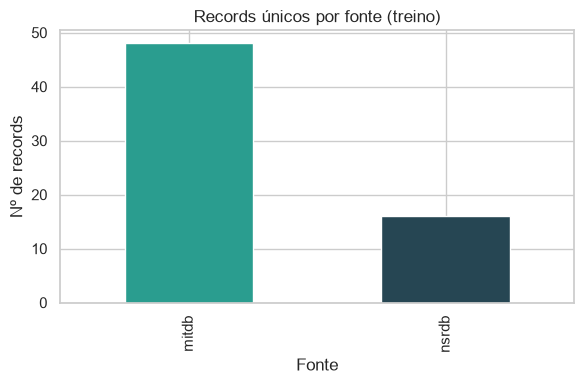

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby("source")["record_id"].nunique().plot(kind="bar", color=["#2a9d8f", "#264653"], ax=ax)
ax.set_title("Records únicos por fonte (treino)")
ax.set_xlabel("Fonte")
ax.set_ylabel("Nº de records")
plt.tight_layout()
plt.show()


**Gráfico 1 — records por fonte.** Mostra quantos exames distintos entraram de `mitdb` (arritmia) e `nsrdb` (sinusal). Desbalanceamento de records é esperado: o Arrhythmia tem mais arquivos curtos; o NSRDB tem poucos sujeitos, porém registros longos (por isso limitamos janelas/amostras).


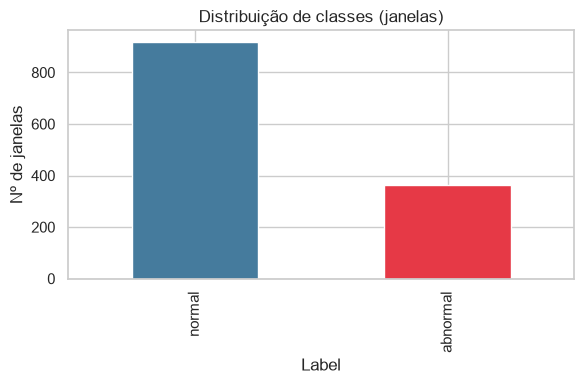

label
normal      0.716
abnormal    0.284
Name: proportion, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar", color=["#457b9d", "#e63946"], ax=ax)
ax.set_title("Distribuição de classes (janelas)")
ax.set_xlabel("Label")
ax.set_ylabel("Nº de janelas")
plt.tight_layout()
plt.show()
print(df["label"].value_counts(normalize=True).round(3))


**Gráfico 2 — classes.** Contagem de janelas `normal` vs `abnormal` após a união. A classe normal tende a dominar (NSRDB inteiro + batimentos N do MIT-BIH). Isso importa para o detector de anomalias: avaliaremos com foco em recall da classe anormal / score de outlier.


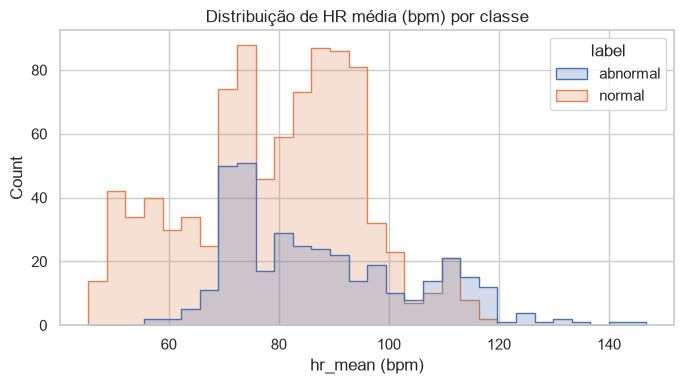

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df.dropna(subset=["hr_mean"]), x="hr_mean", hue="label", bins=30, element="step", ax=ax)
ax.set_title("Distribuição de HR média (bpm) por classe")
ax.set_xlabel("hr_mean (bpm)")
plt.tight_layout()
plt.show()


**Gráfico 3 — histograma de HR.** Compara a frequência cardíaca média das janelas. Janelas anormais podem concentrar HR mais dispersa ou extremos; janelas normais tendem a se agrupar em faixas fisiológicas típicas de repouso/ambulatorial.


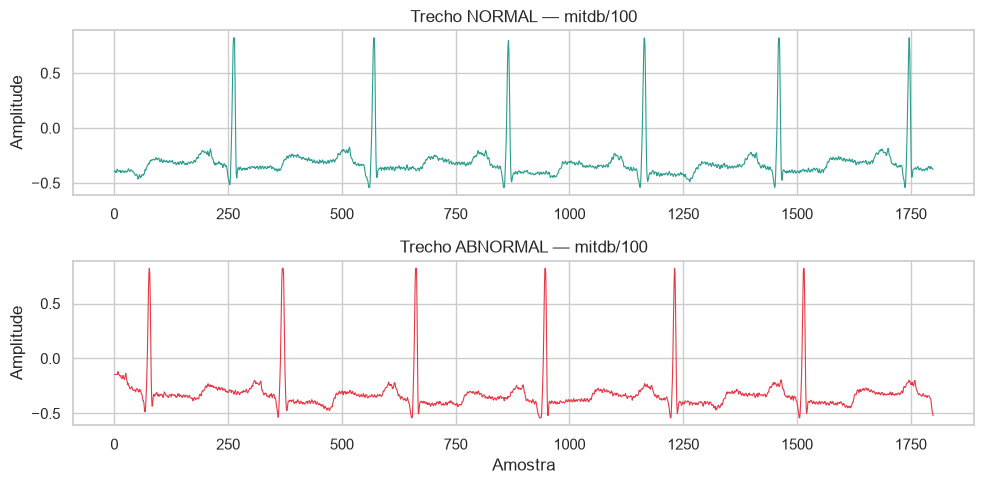

In [13]:
from src.vitals.ecg_preprocess import load_waveform_snippet

normal_row = df[df["label"] == "normal"].iloc[0]
abn = df[df["label"] == "abnormal"]
abnormal_row = abn.iloc[0] if len(abn) else None

snip_n = load_waveform_snippet(
    RAW / normal_row["source"],
    normal_row["record_id"],
    start=int(normal_row["start_sample"]),
    n_samples=int(normal_row["fs"] * 5),
)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=False)
if snip_n:
    sig_n, fs_n = snip_n
    axes[0].plot(sig_n, color="#2a9d8f", lw=0.8)
    axes[0].set_title(f"Trecho NORMAL — {normal_row['source']}/{normal_row['record_id']}")
    axes[0].set_ylabel("Amplitude")

if abnormal_row is not None:
    snip_a = load_waveform_snippet(
        RAW / abnormal_row["source"],
        abnormal_row["record_id"],
        start=int(abnormal_row["start_sample"]),
        n_samples=int(abnormal_row["fs"] * 5),
    )
    if snip_a:
        sig_a, fs_a = snip_a
        axes[1].plot(sig_a, color="#e63946", lw=0.8)
        axes[1].set_title(
            f"Trecho ABNORMAL — {abnormal_row['source']}/{abnormal_row['record_id']}"
        )
        axes[1].set_ylabel("Amplitude")
else:
    axes[1].text(0.5, 0.5, "Sem janelas abnormal no subset atual", ha="center")

axes[1].set_xlabel("Amostra")
plt.tight_layout()
plt.show()


**Gráfico 4 — formas de onda.** Visualização qualitativa de ~5 s de um trecho rotulado como normal versus um anormal. Serve para o professor ver, visualmente, que a união preserva morfologias distintas — base para o módulo de anomalias em vitais.


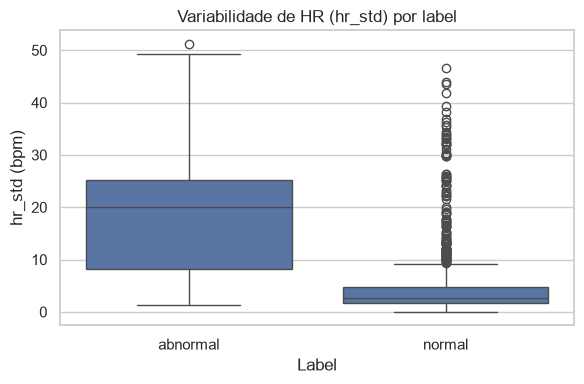

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df.dropna(subset=["hr_std"]), x="label", y="hr_std", ax=ax)
ax.set_title("Variabilidade de HR (hr_std) por label")
ax.set_xlabel("Label")
ax.set_ylabel("hr_std (bpm)")
plt.tight_layout()
plt.show()


**Gráfico 5 — boxplot `hr_std`.** A variabilidade batimento-a-batimento dentro da janela tende a ser maior em trechos anormais (arritmia), o que motiva usar `hr_std` (e correlatas) como feature no Isolation Forest.


In [15]:
resumo = df.groupby(["source", "label"]).agg(
    n_janelas=("record_id", "size"),
    n_records=("record_id", "nunique"),
    hr_mean_mediana=("hr_mean", "median"),
    hr_std_mediana=("hr_std", "median"),
).reset_index()
display(resumo)
display(df.describe().T)


,source,label,n_janelas,n_records,hr_mean_mediana,hr_std_mediana
0,mitdb,abnormal,363,33,84.271514,20.041707
1,mitdb,normal,597,41,73.812127,2.209797
2,nsrdb,normal,320,16,88.348059,3.418517


,count,mean,std,min,25%,50%,75%,max
window_idx,1280.0,9.500000,5.768535,0.000000,4.750000,9.500000,14.250000,19.000000
start_sample,1280.0,28690.000000,20693.575091,0.000000,10800.000000,23680.000000,46800.000000,68400.000000
fs,1280.0,302.000000,100.498212,128.000000,302.000000,360.000000,360.000000,360.000000
n_samples,1280.0,3020.000000,1004.982116,1280.000000,3020.000000,3600.000000,3600.000000,3600.000000
sig_mean,1280.0,-0.271162,0.274206,-1.074275,-0.306006,-0.179808,-0.061492,0.174178
sig_std,1280.0,0.335122,0.146580,0.102374,0.226936,0.301591,0.422614,0.921848
hr_mean,1278.0,81.837776,16.598049,45.377734,71.548238,82.029121,92.345677,146.751954
hr_std,1278.0,8.905008,10.386282,0.000000,1.966076,3.458967,13.416838,51.224864
rr_mean,1278.0,0.782080,0.168046,0.457778,0.661855,0.750126,0.851488,1.328175
rr_std,1278.0,0.074468,0.086522,0.000000,0.020136,0.035851,0.103148,0.532535


**Tabela resumo:** cruza fonte × label com medianas de HR. Confirma que `nsrdb` contribui só para `normal`, enquanto `mitdb` alimenta ambas as classes via anotações `.atr`.


### 4.6 Experimento extra — ECG Fragment High-Risk

O corpus `ecg-fragment-high-risk` permanece em `data/raw/vitals/ecg-fragment-high-risk/` e **não** foi mesclado em `arrhythmia_train.parquet`.

**Uso planejado:** após treinar Isolation Forest / PyOD no conjunto mitdb+nsrdb, avaliar **sensibilidade a eventos críticos** (fragmentos de arritmia perigosa) como teste hold-out de stress — sem contaminar o treino.


## 4.7 Análise de movimento (vídeo — fisioterapia)

Clipes próprios em `data/raw/videos/` simulam a sessão de fisioterapia do paciente fictício **J.S. (pós-AVC)**.

**Pipeline:** MediaPipe Pose Landmarker (amostragem ~3 fps) → ângulos L/R de ombro, quadril e joelho + inclinação de tronco → score de assimetria ∈ [0, 1] → veredito.

| Veredito | Critério (educacional) |
|---|---|
| **CORRETO** | score < 0,25 |
| **ATENCAO** | 0,25 ≤ score < 0,50 |
| **INCORRETO** | score ≥ 0,50 |

YOLOv8 permanece como extensão futura (pessoa/objetos); neste MVP a pose MediaPipe basta para a heurística de assimetria.

> **Aviso:** heurística acadêmica — **não** é diagnóstico clínico.


In [16]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

ROOT = Path("..").resolve()
if not (ROOT / "src").exists():
    ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.video.anomaly_report import analyze_videos_dir

VIDEOS = ROOT / "data" / "raw" / "videos"
print(f"Pasta de vídeos: {VIDEOS}")
print(f"Arquivos mp4: {sorted(p.name for p in VIDEOS.glob('*.mp4'))}")
print("-" * 60)

reports = analyze_videos_dir(VIDEOS, sample_fps=3.0)

rows = []
for r in reports:
    achados = "; ".join(r["achados"])
    print(f"Vídeo   : {r['video_name']}")
    print(f"Veredito: {r['veredito']}")
    print(f"Score   : {r['score']:.4f}  (detecção pose={r['pose_meta']['detection_rate']:.1%})")
    print(f"Achados : {achados}")
    print(f"Métricas: ombro={r['metrics']['shoulder_asym_deg']}, "
          f"quadril={r['metrics']['hip_asym_deg']}, "
          f"joelho={r['metrics']['knee_asym_deg']}, "
          f"tronco={r['metrics']['trunk_lean_deg']}")
    print("-" * 60)
    rows.append({
        "video": r["video_name"],
        "veredito": r["veredito"],
        "score": r["score"],
        "deteccao_pose": round(r["pose_meta"]["detection_rate"], 3),
        "ombro_deg": r["metrics"]["shoulder_asym_deg"],
        "quadril_deg": r["metrics"]["hip_asym_deg"],
        "joelho_deg": r["metrics"]["knee_asym_deg"],
        "tronco_deg": r["metrics"]["trunk_lean_deg"],
        "achados": achados,
    })

df_video = pd.DataFrame(rows)
display(df_video)
print(r["aviso"])


Pasta de vídeos: C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\raw\videos
Arquivos mp4: ['WhatsApp Video 2026-07-27 at 07.48.35.mp4', 'WhatsApp Video 2026-07-27 at 07.48.42.mp4', 'WhatsApp Video 2026-07-27 at 22.03.27.mp4', 'WhatsApp Video 2026-07-27 at 22.03.28.mp4']
------------------------------------------------------------
Vídeo   : WhatsApp Video 2026-07-27 at 07.48.35.mp4
Veredito: CORRETO
Score   : 0.0000  (detecção pose=100.0%)
Achados : simetria articular dentro dos limiares educacionais
Métricas: ombro=2.912900326312581, quadril=5.547452918365252, joelho=7.21763820771983, tronco=0.7602757111383527
------------------------------------------------------------
Vídeo   : WhatsApp Video 2026-07-27 at 07.48.42.mp4
Veredito: CORRETO
Score   : 0.0000  (detecção pose=100.0%)
Achados : simetria articular dentro dos limiares educacionais
Métricas: ombro=3.964259890781584, quadril=4.933911677250762, joelho=9.626270338093775, tronco=2.065819771282653
--------------------

,video,veredito,score,deteccao_pose,ombro_deg,quadril_deg,joelho_deg,tronco_deg,achados
0,WhatsApp Video 2026-07-27 at 07.48.35.mp4,CORRETO,0.0000,1.0,2.91290,5.547453,7.217638,0.760276,simetria articular dentro dos limiares educaci...
1,WhatsApp Video 2026-07-27 at 07.48.42.mp4,CORRETO,0.0000,1.0,3.96426,4.933912,9.626270,2.065820,simetria articular dentro dos limiares educaci...
2,WhatsApp Video 2026-07-27 at 22.03.27.mp4,ATENCAO,0.3125,1.0,NaN,8.837580,11.263088,34.290737,compensação / inclinação de tronco elevada (34...
3,WhatsApp Video 2026-07-27 at 22.03.28.mp4,ATENCAO,0.3125,1.0,NaN,7.245148,9.751809,36.765234,compensação / inclinação de tronco elevada (36...


Heurística acadêmica de assimetria L/R (cenário J.S. pós-AVC). Não constitui diagnóstico clínico.


**Leitura no cenário multimodal:** o score de vídeo alimenta a fusão de risco (`src/fusion/risk_fusion.py`) junto com áudio e vitais. Vereditos `ATENCAO`/`INCORRETO` tipicamente refletem assimetria articular ou compensação de tronco — proxy educacional de padrão motor anômalo na reabilitação pós-AVC.


## 4.8 Análise de áudio — features vocais (UCI Parkinson)

Fonte: **Oxford Parkinson's Disease Detection Dataset** (UCI), em `data/raw/parkinsons/parkinsons.data`.
São **medidas biomédicas de voz já extraídas** (jitter, shimmer, HNR, PPE, etc.) — **não** arquivos WAV.
Complemento: Telemonitoring UPDRS em `data/raw/parkinsons/telemonitoring/`.

**Papel no projeto:** proxy educacional de alteração vocal (análogo a fadiga/disartria no check-in do paciente J.S.). Whisper/STT permanece planejado para clips `.wav` futuros.

**Score de risco vocal** ∈ [0, 1]: média min-max de `PPE`, `spread1`, `MDVP:Jitter(%)`, `MDVP:Shimmer` e `(1 − HNR_norm)`.

> **Aviso:** heurística acadêmica — **não** constitui diagnóstico clínico.


In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path("..").resolve()
if not (ROOT / "src").exists():
    ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.audio.parkinsons_analysis import analyze_parkinsons_dir

sns.set_theme(style="whitegrid", context="notebook")

AUDIO = ROOT / "data" / "raw" / "parkinsons"
result = analyze_parkinsons_dir(AUDIO)
df = result["df"]
tele = result["tele"]

print(f"Pasta: {result['root']}")
print(f"Detection: {result['detection_path']}")
print(f"Telemonitoring: {result['telemonitoring_path']}")
print("-" * 60)
print("Resumo:", result["summary"])
if result["tele_summary"]:
    print("Telemonitoring:", result["tele_summary"])
print("-" * 60)
display(df[["name", "subject", "label", "status", "MDVP:Jitter(%)", "MDVP:Shimmer", "HNR", "PPE", "voice_risk_score"]].head(10))


Pasta: C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\raw\parkinsons
Detection: C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\raw\parkinsons\parkinsons.data
Telemonitoring: C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\raw\parkinsons\telemonitoring\parkinsons_updrs.data
------------------------------------------------------------
Resumo: {'n_rows': 195, 'n_subjects': 32, 'status_counts': {0: 48, 1: 147}, 'label_counts': {'PD': 147, 'saudavel': 48}, 'feature_means_by_label': {'MDVP:Jitter(%)': {'PD': 0.007, 'saudavel': 0.0039}, 'MDVP:Shimmer': {'PD': 0.0337, 'saudavel': 0.0176}, 'HNR': {'PD': 20.974, 'saudavel': 24.6787}, 'PPE': {'PD': 0.2338, 'saudavel': 0.123}, 'spread1': {'PD': -5.3334, 'saudavel': -6.7593}}, 'key_features': ['MDVP:Jitter(%)', 'MDVP:Shimmer', 'HNR', 'PPE', 'spread1']}
Telemonitoring: {'n_rows': 5875, 'n_subjects': 42, 'total_UPDRS_mean': 29.01894228085106, 'motor_UPDRS_mean': 21.29622854468085}
-----------------------

,name,subject,label,status,MDVP:Jitter(%),MDVP:Shimmer,HNR,PPE,voice_risk_score
0,phon_R01_S01_1,S01,PD,1,0.00784,0.04374,21.033,0.284654,0.384717
1,phon_R01_S01_2,S01,PD,1,0.00968,0.06134,19.085,0.368674,0.452498
2,phon_R01_S01_3,S01,PD,1,0.01050,0.05233,20.651,0.332634,0.426906
3,phon_R01_S01_4,S01,PD,1,0.00997,0.05492,20.644,0.368975,0.431601
4,phon_R01_S01_5,S01,PD,1,0.01284,0.06425,19.649,0.410335,0.478721
5,phon_R01_S01_6,S01,PD,1,0.00968,0.04701,21.378,0.357775,0.409244
6,phon_R01_S02_1,S02,PD,1,0.00333,0.01608,24.886,0.211756,0.273746
7,phon_R01_S02_2,S02,PD,1,0.00290,0.01567,26.892,0.163755,0.253361
8,phon_R01_S02_3,S02,PD,1,0.00551,0.02093,21.812,0.231571,0.324740
9,phon_R01_S02_4,S02,PD,1,0.00532,0.02838,21.862,0.271362,0.335608


**Inventário:** 195 gravações / ~32 sujeitos; classe `PD` é majoritária. A coluna `voice_risk_score` já resume a heurística por registro para alimentar a fusão multimodal.


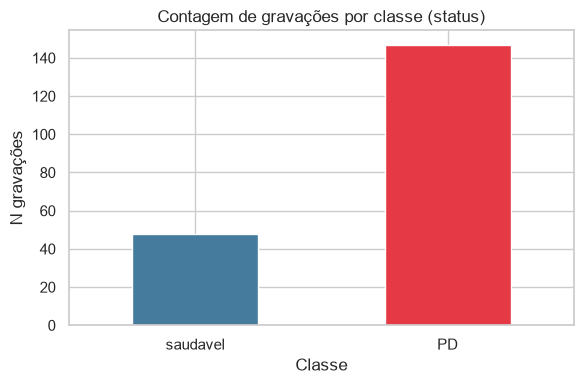

{'saudavel': 48, 'PD': 147}


In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["saudavel", "PD"]
counts = df["label"].value_counts().reindex(order)
counts.plot(kind="bar", color=["#457b9d", "#e63946"], ax=ax)
ax.set_title("Contagem de gravações por classe (status)")
ax.set_xlabel("Classe")
ax.set_ylabel("N gravações")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts.to_dict())


**Gráfico 1 — classes.** Distribuição saudável vs PD no corpus de detecção. O desbalanceamento é esperado (mais amostras PD) e deve ser considerado ao interpretar acurácia futura.


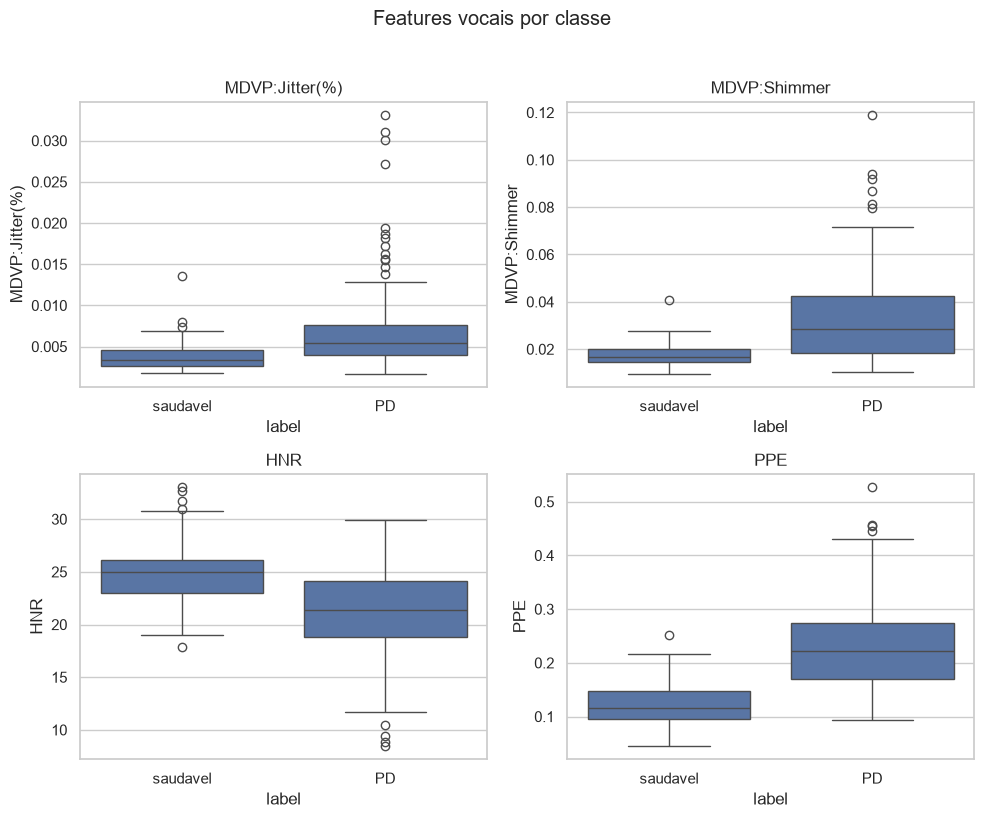

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
feats = ["MDVP:Jitter(%)", "MDVP:Shimmer", "HNR", "PPE"]
for ax, feat in zip(axes.ravel(), feats):
    sns.boxplot(data=df, x="label", y=feat, order=["saudavel", "PD"], ax=ax)
    ax.set_title(feat)
plt.suptitle("Features vocais por classe", y=1.02)
plt.tight_layout()
plt.show()


**Gráfico 2 — boxplots.** PD tende a jitter/shimmer/PPE mais altos e HNR mais baixo — padrão clássico de maior instabilidade fonatória, útil como proxy de risco de fala no MVP.


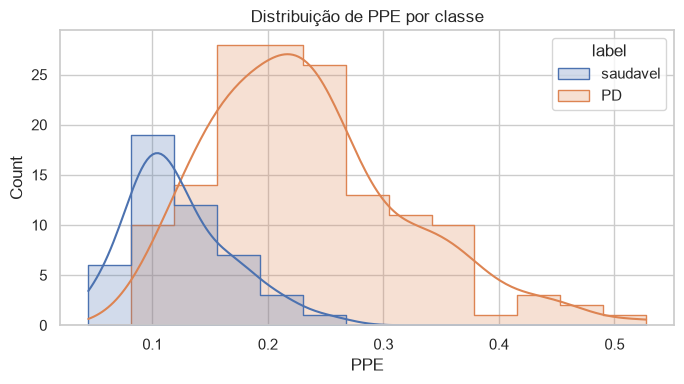

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="PPE", hue="label", hue_order=["saudavel", "PD"], kde=True, element="step", ax=ax)
ax.set_title("Distribuição de PPE por classe")
plt.tight_layout()
plt.show()


**Gráfico 3 — PPE.** A pitch period entropy separa bem os grupos; valores altos associam-se a maior risco na heurística `score_voice_risk`.


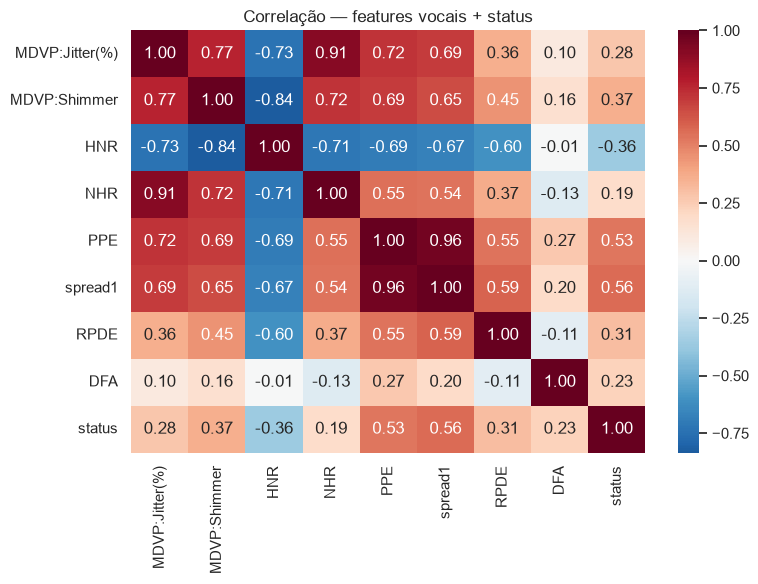

In [21]:
corr_cols = result["corr_features"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlação — features vocais + status")
plt.tight_layout()
plt.show()


**Gráfico 4 — heatmap.** `status` correlaciona positivamente com PPE/jitter/shimmer e negativamente com HNR, sustentando o peso dessas variáveis no score.


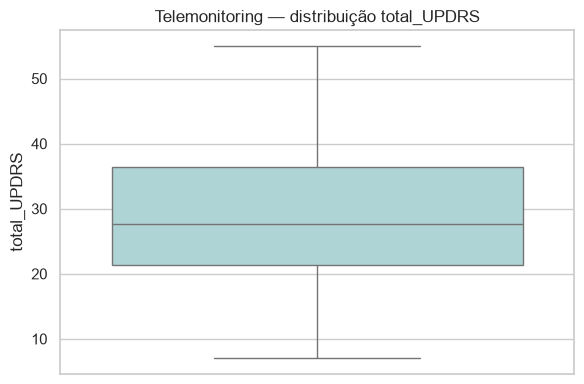

count    5875.00
mean       29.02
std        10.70
min         7.00
25%        21.37
50%        27.58
75%        36.40
max        54.99
Name: total_UPDRS, dtype: float64


In [22]:
if tele is not None and "total_UPDRS" in tele.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=tele, y="total_UPDRS", color="#a8dadc", ax=ax)
    ax.set_title("Telemonitoring — distribuição total_UPDRS")
    plt.tight_layout()
    plt.show()
    print(tele["total_UPDRS"].describe().round(2))
else:
    print("Telemonitoring indisponível.")


**Gráfico 5 — UPDRS (telemonitoring).** Severidade clínica agregada no corpus longitudinal; complementar à classificação binária do detection set (não misturado no score do MVP).


In [23]:
print("Top sujeitos por mediana do voice_risk_score:")
display(result["top_subjects"])
print("-" * 60)
print(result["aviso"])


Top sujeitos por mediana do voice_risk_score:


,subject,voice_risk_score,label,status
0,S35,0.568807,PD,1
1,S24,0.547159,PD,1
2,S21,0.455044,PD,1
3,S01,0.429253,PD,1
4,S33,0.396257,PD,1
5,S05,0.395350,PD,1
6,S18,0.382450,PD,1
7,S31,0.365889,PD,1
8,S16,0.365067,PD,1
9,S50,0.364281,saudavel,0


------------------------------------------------------------
Proxy educacional com features vocais UCI Parkinson (Oxford). Nao e WAV/Whisper nem diagnostico clinico; Whisper fica para clips .wav futuros.


**Leitura multimodal:** o `voice_risk_score` (mediana por sujeito ou por gravação) pode entrar na fusão (`src/fusion/risk_fusion.py`) como `audio_score`, junto com o score de assimetria de vídeo e anomalias de vitais.


## 4.9 Detecção de anomalias em vitais (E1 — Isolation Forest)

Experimento **E1**: série sintética HR/SpO₂/SBP/DBP (noite do paciente J.S.) com anomalias injetadas
e treino de **Isolation Forest** (`sklearn`) via `src/vitals/anomaly_detection.py`.

Experimento detalhado: [`01_vitals_sinteticos.ipynb`](01_vitals_sinteticos.ipynb).  
Artefatos: `data/raw/vitals/synthetic/js001_noite.csv`, `data/processed/vitals/isolation_forest_vitals.joblib` + `_meta.json`.

> **Aviso:** sintético educacional — não é diagnóstico clínico.


In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path("..").resolve()
if not (ROOT / "src").exists():
    ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.vitals.synthetic_vitals import load_or_create_synthetic, summarize_synthetic
from src.vitals.anomaly_detection import (
    run_training_pipeline,
    load_train_meta,
    default_meta_path,
    default_model_path,
    load_model,
    detect_anomalies,
)

sns.set_theme(style="whitegrid", context="notebook")

CSV = ROOT / "data" / "raw" / "vitals" / "synthetic" / "js001_noite.csv"
MODEL = default_model_path(ROOT)
META = default_meta_path(ROOT)

df, csv_path = load_or_create_synthetic(path=CSV, force=not CSV.exists())
print("CSV:", csv_path)
print("Resumo série:", summarize_synthetic(df))

# Treina (ou retreina) e persiste — deixa params/métricas visíveis no Relatorio
result = run_training_pipeline(df, contamination=0.05, n_estimators=200, random_state=42)
meta = result["meta"]

print("-" * 60)
print("HIPERPARÂMETROS / TREINO")
for k in ("model_name", "n_estimators", "contamination", "random_state", "feature_cols", "n_samples"):
    print(f"  {k}: {meta.get(k)}")
print("-" * 60)
print("RESULTADOS")
print(f"  n_anomalies_gt  : {meta.get('n_anomalies_gt')}")
print(f"  n_anomalies_pred: {meta.get('n_anomalies_pred')}")
print(f"  risk_score      : {meta.get('risk_score'):.4f}")
print(f"  metrics         : {meta.get('metrics')}")
print(f"  model_path      : {meta.get('model_path')}")
print(f"  meta_path       : {result['meta_path']}")
print("-" * 60)
display(pd.DataFrame([
    {"campo": "n_estimators", "valor": meta["n_estimators"]},
    {"campo": "contamination", "valor": meta["contamination"]},
    {"campo": "random_state", "valor": meta["random_state"]},
    {"campo": "feature_cols", "valor": ", ".join(meta["feature_cols"])},
    {"campo": "n_samples", "valor": meta["n_samples"]},
    {"campo": "n_anomalies_gt", "valor": meta["n_anomalies_gt"]},
    {"campo": "n_anomalies_pred", "valor": meta["n_anomalies_pred"]},
    {"campo": "risk_score", "valor": round(meta["risk_score"], 4)},
    {"campo": "precision", "valor": meta["metrics"]["precision"] if meta.get("metrics") else None},
    {"campo": "recall", "valor": meta["metrics"]["recall"] if meta.get("metrics") else None},
    {"campo": "f1", "valor": meta["metrics"]["f1"] if meta.get("metrics") else None},
]))
print(meta.get("aviso", ""))


CSV: C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\raw\vitals\synthetic\js001_noite.csv
Resumo série: {'n_samples': 25200, 'n_anomalies_gt': 2160, 'anomaly_rate_gt': 0.08571428571428572, 'duration_hours': 6.999722222222222, 'feature_means': {'HR': 69.49550396825397, 'SpO2': 96.62685396825398, 'SBP': 118.79294801587302, 'DBP': 72.24765595238095}}
------------------------------------------------------------
HIPERPARÂMETROS / TREINO
  model_name: sklearn.IsolationForest
  n_estimators: 200
  contamination: 0.05
  random_state: 42
  feature_cols: ['HR', 'SpO2', 'SBP', 'DBP']
  n_samples: 25200
------------------------------------------------------------
RESULTADOS
  n_anomalies_gt  : 2160
  n_anomalies_pred: 1260
  risk_score      : 0.8557
  metrics         : {'precision': 1.0, 'recall': 0.5833333333333334, 'f1': 0.7368421052631579}
  model_path      : C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\processed\vitals\isolation_forest_vitals.joblib
  meta_path

campo,valor
n_estimators,200
contamination,0.05
random_state,42
feature_cols,"HR, SpO2, SBP, DBP"
n_samples,25200
n_anomalies_gt,2160
n_anomalies_pred,1260
risk_score,0.8557
precision,1.0
recall,0.583333


**Treino visível:** a tabela acima resume hiperparâmetros e métricas contra o ground truth injetado (`is_anomaly`). O `risk_score` ∈ [0, 1] é a média dos top-5% scores normalizados — candidato a `vitals_score` na fusão multimodal.


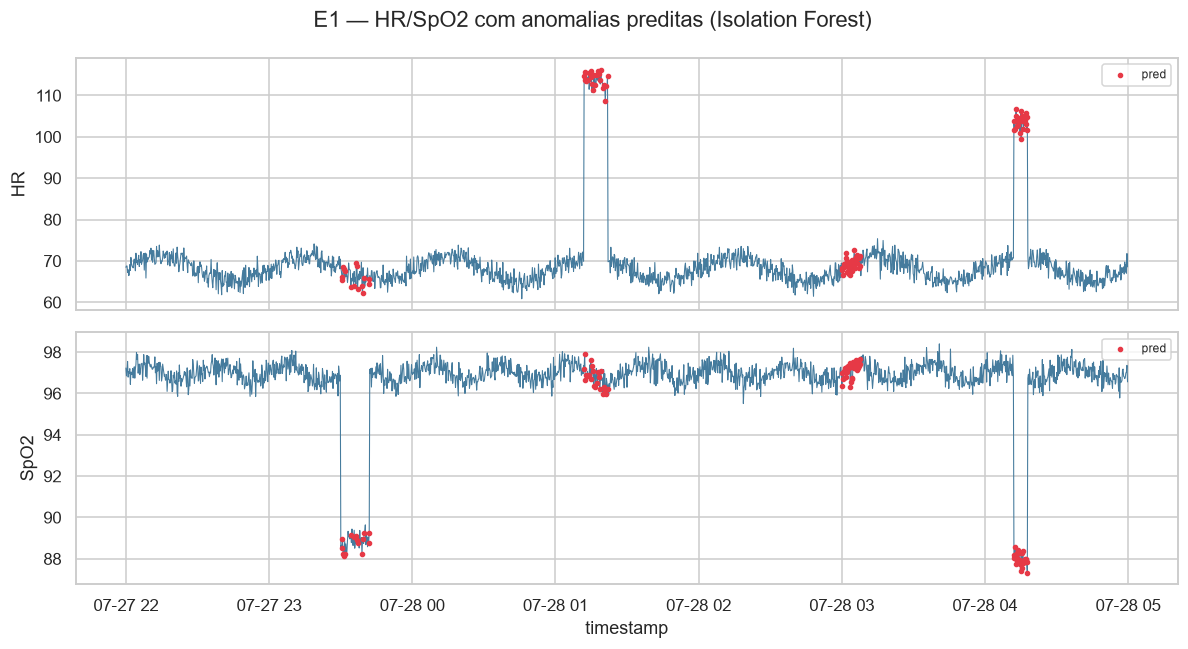

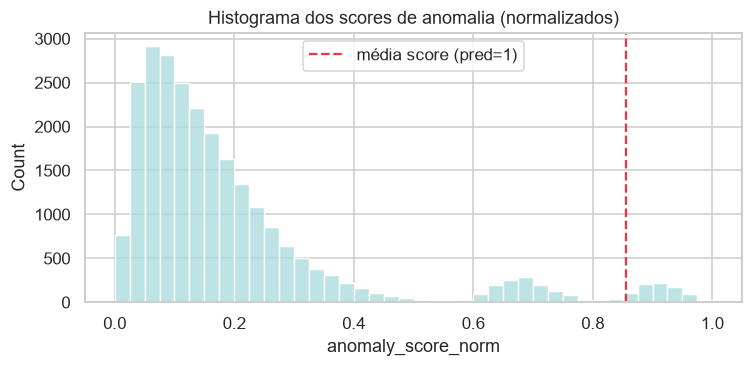

In [1]:
points = result["points"]
step = max(1, len(points) // 1800)
vis = points.iloc[::step]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, col in zip(axes, ["HR", "SpO2"]):
    ax.plot(vis["timestamp"], vis[col], color="#457b9d", lw=0.7)
    pred = vis[vis["anomaly_pred"] == 1]
    ax.scatter(pred["timestamp"], pred[col], c="#e63946", s=7, label="pred", zorder=3)
    ax.set_ylabel(col)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("timestamp")
plt.suptitle("E1 — HR/SpO2 com anomalias preditas (Isolation Forest)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(points["anomaly_score_norm"], bins=40, color="#a8dadc", ax=ax)
ax.axvline(points.loc[points["anomaly_pred"] == 1, "anomaly_score_norm"].mean(),
           color="#e63946", ls="--", label="média score (pred=1)")
ax.set_title("Histograma dos scores de anomalia (normalizados)")
ax.legend()
plt.tight_layout()
plt.show()


**Leitura no cenário J.S.:** episódios de SpO₂ baixa / taquicardia injetados na noite sintética devem elevar o score de vitais. Na etapa de fusão, este `risk_score` combina com assimetria de vídeo e `voice_risk_score` de áudio.


## 5. Stack e modelos

| Camada | Tecnologia | Papel |
|---|---|---|
| Vídeo | MediaPipe Pose, YOLOv8, OpenCV | Landmarks articulares e eventos visuais |
| Áudio | Whisper, librosa | Transcrição e features de fala |
| NLP | Transformers | Termos críticos / sentimento (proxy Text Analytics) |
| Vitais | scikit-learn Isolation Forest, PyOD | Anomalias em séries temporais |
| Fusão | Score ponderado (`risk_fusion.py`) | Combina risco vídeo + áudio + vitais |
| LLM demo | Ollama `llama3.2` | Resumo/alerta rápido |
| LLM médico | Meta-Llama-3-8B-Instruct + LoRA médico | Relatório clínico educacional |

Paths locais (`.env`):

```env
LOCAL_LLAMA_MODEL_PATH=./models/base/Meta-Llama-3-8B-Instruct
MEDICAL_ADAPTER_PATH=./models/llama3-8b-bnb-4bit-medical/adapter
```

Download dos pesos Hugging Face:

```powershell
python -m src.fine_tuning.download_local_llama
```

In [24]:
from pathlib import Path
import os

from dotenv import load_dotenv

ROOT = Path("..").resolve()
if not (ROOT / "requirements.txt").exists():
    ROOT = Path(".").resolve()

load_dotenv(ROOT / ".env")

paths = {
    "root": ROOT,
    "data_raw": ROOT / "data" / "raw",
    "data_processed": ROOT / "data" / "processed",
    "llama_base": ROOT / os.getenv("LOCAL_LLAMA_MODEL_PATH", "./models/base/Meta-Llama-3-8B-Instruct"),
    "medical_adapter": ROOT / os.getenv("MEDICAL_ADAPTER_PATH", "./models/llama3-8b-bnb-4bit-medical/adapter"),
}

for name, path in paths.items():
    exists = path.exists() if name != "root" else True
    print(f"{name:18} | exists={exists} | {path}")

root               | exists=True | C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais
data_raw           | exists=True | C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\raw
data_processed     | exists=True | C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\data\processed
llama_base         | exists=True | C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\models\base\Meta-Llama-3-8B-Instruct
medical_adapter    | exists=True | C:\Users\stefa\Documents\Cursos\TechChallenge-Multimodais\models\llama3-8b-bnb-4bit-medical\adapter


## 6. Cenário do paciente fictício (fio condutor)

**Paciente:** J.S., 68 anos, pós-AVC, em reabilitação motora com monitoramento de UTI step-down.

| Turno | Modalidade | Evento simulado | Score esperado |
|---|---|---|---|
| Manhã | Vídeo — fisioterapia de marcha assistida | Assimetria de joelho / compensação de tronco | Risco motor ↑ |
| Tarde | Áudio — check-in de enfermagem | Fala arrastada, menção a “falta de ar” e fadiga | Risco de fala / sintomas ↑ |
| Noite | Vitais + prescrição | Queda de SpO₂ + taquicardia; dose de analgésico alterada fora do protocolo | Risco vital / prescrição ↑ |

**Fusão:** combinação ponderada dos três scores → risco global.  
**Motor de alertas:** LLM gera resumo em Markdown para a equipe (nível baixo / médio / alto).

Esse cenário único permite demonstrar no vídeo de entrega o fluxo completo: ingestão → modelos → fusão → alerta.

In [25]:
# Esqueleto do paciente fictício (metadados do caso)
paciente = {
    "id": "JS-001",
    "idade": 68,
    "contexto": "pos-AVC / reabilitacao / UTI step-down",
    "modalidades": {
        "video": {
            "arquivo": "data/raw/videos/",
            "achado_esperado": "assimetria articular / compensacao de tronco",
        },
        "audio": {
            "arquivo": "data/raw/parkinsons/parkinsons.data",
            "achado_esperado": "disartria leve + termos de fadiga/dispneia",
        },
        "vitals": {
            "arquivo": "data/raw/vitals/synthetic/js001_noite.csv",
            "achado_esperado": "SpO2 baixa + taquicardia + desvio de prescricacao",
        },
    },
}

print(f"Caso {paciente['id']} — {paciente['contexto']}")
for mod, info in paciente["modalidades"].items():
    print(f"  [{mod}] {info['arquivo']}")
    print(f"         esperado: {info['achado_esperado']}")

Caso JS-001 — pos-AVC / reabilitacao / UTI step-down
  [video] data/raw/videos/
         esperado: assimetria articular / compensacao de tronco
  [audio] data/raw/parkinsons/parkinsons.data
         esperado: disartria leve + termos de fadiga/dispneia
  [vitals] data/raw/vitals/js001_noite.csv
         esperado: SpO2 baixa + taquicardia + desvio de prescricacao


## 7. Pipeline (visão operacional)

1. **Ingestão** dos dados brutos em `data/raw/{video,audio,vitals}`.
2. **Feature extraction** por modalidade → artefatos em `data/processed/`.
3. **Inferência** (`src/video`, `src/audio`, `src/vitals`) → score ∈ [0, 1] + achados.
4. **Fusão** (`src/fusion`) → risco global + breakdown.
5. **LLM + alerta** (`src/llm`, `src/alerts`) → resumo para a equipe.

**Tempo real:** no MVP, simulamos streaming por **janelas deslizantes** sobre as séries/vídeo/áudio (batch quase online), adequado para demo acadêmica sem infra de edge clínica.

## 8. Próximos experimentos (roadmap)

Notebooks futuros sugeridos (ainda não implementados nesta etapa):

| Notebook | Foco |
|---|---|
| `01_vitals_sinteticos.ipynb` | Gerar HR/SpO₂/PA + injetar anomalias; treinar Isolation Forest / PyOD |
| `02_audio_fala.ipynb` | Whisper + features de fadiga/disartria + termos críticos |
| `03_video_pose.ipynb` | MediaPipe/YOLOv8 em clipe próprio; desvio angular |
| `04_fusao_alertas.ipynb` | Combinar scores + Ollama/LoRA médico + notificação |

### Fora do escopo desta etapa

- Download completo PhysioNet/MIMIC
- Treino pesado / fine-tuning adicional
- Gravação definitiva dos clips de demo
- Implementação completa dos stubs em `src/*`
- Edição do vídeo YouTube/Vimeo (≤ 15 min)

In [26]:
# Placeholder: checklist de experimentos (marcar conforme avanço)
experimentos = [
    {"id": "E1", "nome": "Vitais sintéticos + Isolation Forest", "feito": True},
    {"id": "E2", "nome": "Features vocais Parkinson (UCI)", "feito": True},
    {"id": "E3", "nome": "Pose MediaPipe em vídeo próprio", "feito": True},
    {"id": "E4", "nome": "Fusão dos 3 scores", "feito": False},
    {"id": "E5", "nome": "Alerta LLM (Ollama / LoRA médico)", "feito": False},
]

for e in experimentos:
    mark = "[x]" if e["feito"] else "[ ]"
    print(f"{mark} {e['id']} — {e['nome']}")

[ ] E1 — Vitais sintéticos + Isolation Forest
[x] E2 — Features vocais Parkinson (UCI)
[x] E3 — Pose MediaPipe em vídeo próprio
[ ] E4 — Fusão dos 3 scores
[ ] E5 — Alerta LLM (Ollama / LoRA médico)


## 9. Checklist de entrega (itens fáceis de esquecer)

Conforme o PDF da Fase 4 (atividade obrigatória, ~90% da nota das disciplinas da fase):

### Repositório Git
- [ ] Código-fonte completo da solução
- [ ] README com setup e arquitetura
- [ ] Dados de exemplo (ou script de geração) em `data/`
- [ ] Este relatório técnico evoluído com **resultados e exemplos de anomalias**

### Relatório técnico (conteúdo mínimo)
- [ ] Descrição do **fluxo multimodal**
- [ ] **Modelos** aplicados em cada tipo de dado
- [ ] **Resultados** obtidos e exemplos de anomalias detectadas
- [ ] Justificativa da substituição Azure → stack local
- [ ] Limitações (vídeo simulado, dados sintéticos, aviso ético)

### Vídeo demo (≤ 15 min · YouTube/Vimeo)
- [ ] Análise prática de **áudio e vídeo**
- [ ] Detecção e resposta a **anomalias**
- [ ] Explicação da “integração cloud” **via equivalência local** (ou Azure free, se usado)
- [ ] Fluxo final do **alerta à equipe médica**

### Detalhes técnicos frequentemente esquecidos
- [ ] Modalidade **texto** (prescrição / evolução clínica), além de áudio e vídeo
- [ ] Padrões de **movimentação** na internação (vídeo + features temporais)
- [ ] Definição operacional de **tempo real** (janelas)
- [ ] Aviso de que o LLM médico é educacional
- [ ] Evidências (prints/gráficos) dos três scores e do score fusionado

## 10. Resultados (a preencher)

_Esta seção será preenchida após os experimentos E1–E5._

| Modalidade | Métrica / evidência | Exemplo de anomalia |
|---|---|---|
| Vídeo | _pendente_ | _pendente_ |
| Áudio | _pendente_ | _pendente_ |
| Vitais | _pendente_ | _pendente_ |
| Fusão + alerta | _pendente_ | _pendente_ |

---

**E1 concluído:** ver §4.9 e `01_vitals_sinteticos.ipynb`. Próximo: fusão dos scores / áudio Whisper ou prescrição.